# Traffic Accident Analysis 

This notebook is for analyzing traffic accident data provided by the Finnish Transport Infrastructure Agency in order to find factors associated with accident severity and to discover typical accident patterns. 

### Research Question 1: Can accident severity be predicted based on the available features?
### Research Question 2: How much do weather conditions affect accident severity?
### Research Question 3: Are there identifiable accident profiles (clusters)?

The first two are classification problems, while the third is an unsupervised learning problem. Suitable models for classification include Decision Trees, Random Forests and Logistic Regression while for clustering the K-Means algorithm can be used.

# Data Understanding
The data is in CSV format per year and contains information about traffic accidents in Finland. The data can be fetched from this URL: https://aineistot.vayla.fi/spa/ava/Tie/Tieliikenneonnettomuudet/

In readme.txt file, it is mentioned that not all years have the same columns and also that the data model changed in 2022 dividing the data into pre and post 2022 datasets. As this project was done as a part of a course and the focus on the analysis would be on modeling, only a moderate effort was put into the issue of combining the datasets. During closer inspection, it was also discovered that the different datasets had different encodings which would have to be taken into consideration when reading and parseing the data.

In the code cell below is a simple approach of inspectin the combination of the datasets. If all data from the years 2015-2024 were combined, the resulting dataset would have 0 common columns. The dataset for the year 2024 is not finalized and had a completely different structure and thus made it impossible to combine with the other datasets. After dropping the 2024 dataset, the combined dataset for years 2015-2023 had 12 common columns and after some slight normalization of column names, the amount of common columns increased to 16. With data from the years 2015-2021, the amount of common columns was 95. 


In [64]:
# ENNEN PALAUTUSTA TÄHÄN prepare_data.ipynb:in EKA SOLU!
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier




As the focus of the analysis is on modeling, the dataset for years 2015-2021 was chosen for further analysis as it had the most common columns with equal data types making it the most suitable for modeling without spending too much time on data cleaning and preprocessing. Another solution would be to pick the data after 2022, but this would have resulted in a much smaller dataset with only 3 years of data and thus was not chosen. In the following code cell the dataset for years 2015-2021 is read into a dataframe for further preprocessing. The datapackage.json is used to get the dtypes of the columns to make sure that the data is read with the correct dtypes.

In [65]:
# ENNEN PALAUTUSTA TÄHÄN prepare_data.ipynb:in TOKA SOLU!

In [66]:
combined_df = pd.read_parquet("combined_2015_2021.parquet")
combined_df.head()

,Onnett_id,Tienpit,Tienpitsel,Tie,Aosa,Aet,Ajr,Vuosi,Kk,Vakavuusko,...,Poikkileik,Poikleikse,Päällyslev,Päällystlk,Päällksel,Nakos150,Nakos300,Nakos460,Runkotie,Raskos
0,6891249,1,Liikennevirasto,1,2,2554,1,2015,9,0,...,2,2 ajor,<NA>,-1,Ei arvoa,<NA>,<NA>,<NA>,0,ei
1,6584643,1,Liikennevirasto,1,3,3,2,2015,10,0,...,2,2 ajor,114,10,kovat asfaltit,97,76,57,1,ei
2,6681113,1,Liikennevirasto,1,3,6,2,2015,1,0,...,2,2 ajor,114,10,kovat asfaltit,97,76,57,1,ei
3,6840692,1,Liikennevirasto,1,3,8,1,2015,7,0,...,2,2 ajor,104,10,kovat asfaltit,97,76,57,1,ei
4,6740912,1,Liikennevirasto,1,3,9,2,2015,10,0,...,2,2 ajor,114,10,kovat asfaltit,97,76,57,1,ei


In [67]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116106 entries, 0 to 116105
Data columns (total 95 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Onnett_id    116106 non-null  Int64 
 1   Tienpit      116106 non-null  Int64 
 2   Tienpitsel   116106 non-null  string
 3   Tie          75773 non-null   Int64 
 4   Aosa         75498 non-null   Int64 
 5   Aet          62619 non-null   Int64 
 6   Ajr          62603 non-null   Int64 
 7   Vuosi        116106 non-null  Int64 
 8   Kk           116106 non-null  Int64 
 9   Vakavuusko   116106 non-null  Int64 
 10  Vakavuus     116106 non-null  string
 11  ELY          116106 non-null  Int64 
 12  Elynimi      116106 non-null  string
 13  Vkpv         116106 non-null  string
 14  Ontyyppi     116106 non-null  Int64 
 15  Ontyypsel    116106 non-null  string
 16  Onluokka     116106 non-null  Int64 
 17  Onlksel      116106 non-null  string
 18  Osallkm      116106 non-null  Int64 
 19  No

# Data Preparation

At this point the dataset includes 95 columns and 116106 rows. The data preparation starts with feature selection and feature engineering. The rows are then inspected and possible outliers and missing values are handled. The dataframes are then split into classification datasets with the severity as target variable ("Vakavuus"). The target variable is dropped for the dataframe used in clustering because we want to find patterns independent of severity. 

Further inspection of the columns revealed that the "sel"-columns are categorical variables that explain the integer values in their counterpart columns. For example, Tienpit value 1 is explained in Tienpitsel as "Liikennevirasto". The descriptive column is not always formed by simply adding "-sel" to the category column name and this makes it fairly difficult to map categories to their descriptions during analysis. That is why a mapping approach was implemented to link each integer code to its corresponding description.

Mapping directories are created in the code cell below. For easy access the integer-to-category mappings were also exported as visual tables for each column. They are stored in the directory feature_class_tables. That part of the code is commented out and should be uncommented if need for new tables.

In [68]:

# -------------------------
# Create mapping tables for integer code features
# -------------------------

# -------------------------
# SEL-based mappings (automatic)
# -------------------------
cols = combined_df.columns.tolist()
int_desc_pairs = []
for i, col in enumerate(cols):
    if col.endswith('sel') and i > 0:
        int_col = cols[i-1]
        int_desc_pairs.append((int_col, col))

mapping_dicts = {}
for int_col, sel_col in int_desc_pairs:
    mask = combined_df[[int_col, sel_col]].notna().all(axis=1)
    mapping_dict = dict(zip(combined_df.loc[mask, int_col],
                            combined_df.loc[mask, sel_col]))
    mapping_dicts[int_col] = mapping_dict
    combined_df.drop(columns=[sel_col], inplace=True)  # optional

# -------------------------
# Manual mappings for specific int/string pairs
# -------------------------
manual_pairs = [
    ("Vakavuusko", "Vakavuus"),
    ("ELY", "Elynimi"),
    ("Tienverkas", "Tienverkse"),
    ("Maankäyttö", "Maankäytse"),
    ("Lisäkaisty", "Lisäkaisse"),
    ("Solmutyyp", "Solmutyyps"),
    ("Poikkileik", "Poikleikse")
]

for int_col, str_col in manual_pairs:
    mask = combined_df[[int_col, str_col]].notna().all(axis=1)
    mapping_dict = dict(zip(combined_df.loc[mask, int_col],
                            combined_df.loc[mask, str_col]))
    mapping_dicts[int_col] = mapping_dict
    combined_df.drop(columns=[str_col], inplace=True)  # optional




# -------------------------
# Feature class tables
# -------------------------
# Most recent tables in feature_class_tables directory

# -------------------------  Uncomment if you want to create new tables  ------------------------- #
# # Make folder to store tables
# output_dir = "feature_class_tables"
# os.makedirs(output_dir, exist_ok=True)

# def save_mapping_table(mapping_dict, feature_name, output_dir):
#     # Convert np.int64 keys to plain int
#     cleaned_dict = {int(k): v for k, v in mapping_dict.items()}

#     # Create a DataFrame
#     df = pd.DataFrame(list(cleaned_dict.items()), columns=[feature_name, f"{feature_name}_desc"])
#     df = df.sort_values(by=feature_name)

#     # Plot table
#     fig, ax = plt.subplots(figsize=(6, len(df)*0.25 + 1))  # height proportional to rows
#     ax.axis('off')

#     table = ax.table(cellText=df.values,
#                      colLabels=df.columns,
#                      cellLoc='left',
#                      loc='center')

#     table.auto_set_font_size(False)
#     table.set_fontsize(10)
#     table.auto_set_column_width([0, 1])

#     plt.tight_layout()
#     filename = os.path.join(output_dir, f"{feature_name}_classes.png")
#     plt.savefig(filename, dpi=300, bbox_inches='tight')
#     plt.close()
#     print(f"Saved: {filename}")

# # Loop through all your mapping dictionaries
# for feature, mapping in mapping_dicts.items():
#     save_mapping_table(mapping, feature, output_dir)

In [69]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116106 entries, 0 to 116105
Data columns (total 63 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Onnett_id   116106 non-null  Int64 
 1   Tienpit     116106 non-null  Int64 
 2   Tie         75773 non-null   Int64 
 3   Aosa        75498 non-null   Int64 
 4   Aet         62619 non-null   Int64 
 5   Ajr         62603 non-null   Int64 
 6   Vuosi       116106 non-null  Int64 
 7   Kk          116106 non-null  Int64 
 8   Vakavuusko  116106 non-null  Int64 
 9   ELY         116106 non-null  Int64 
 10  Vkpv        116106 non-null  string
 11  Ontyyppi    116106 non-null  Int64 
 12  Onluokka    116106 non-null  Int64 
 13  Osallkm     116106 non-null  Int64 
 14  Nopraj      116106 non-null  Int64 
 15  Taajmerk    116106 non-null  Int64 
 16  Pinta       116106 non-null  Int64 
 17  Valoisuus   116106 non-null  Int64 
 18  Sää         116106 non-null  Int64 
 19  Onnpaikka   116106 non-

The dataframe now consists mostly of numerical columns. The next step is to review columns that are not clearly explained and remove columns with a high proportion of missing values. Columns with many missing values are identified by calculating the percentage of missing entries for each column and sorting the results in descending order. Columns with the highest percentages of missing values are then removed from the dataframe.

In [70]:
# -------------------------
# Feature selection
# -------------------------

# Listing columns with most NA:s
combined_df.isna().mean().sort_values(ascending=False).head(20)


Liittyvtie    1.000000
Lähliittie    0.957995
Suuntlkm      0.948349
Nakos300      0.610658
Nakos150      0.610658
Nakos460      0.610658
Luovpvm       0.583252
Päällyslev    0.488459
Raskaskvl     0.472603
Kvl           0.471991
Tienlev       0.467934
Runkotie      0.462706
Ajr           0.460812
Aet           0.460674
Aosa          0.349749
Tie           0.347381
Lämpötila     0.004677
Y             0.000474
X             0.000465
Nopraj        0.000000
dtype: float64

In [71]:
# Listing columns with most -1, which also means missing values
missing_with_minus1 = {}
for col in combined_df.select_dtypes("integer"):
    n_missing = combined_df[col].isna().sum() + (combined_df[col] == -1).sum()
    missing_with_minus1[col] = n_missing / len(combined_df)

# Show top 20
pd.Series(missing_with_minus1).sort_values(ascending=False).head(30)

Valoohjaus    1.000000
Muuliit       1.000000
Rautatie      0.997692
Lisäkaisty    0.972387
Lähliittie    0.957995
Liitluok      0.948358
Suuntlkm      0.948349
Solmutyyp     0.948349
Mo_mol        0.944757
Liikvalot     0.908773
Maankäyttö    0.804368
Tienverkas    0.804368
Valaisomis    0.724958
Nakos300      0.610658
Nakos150      0.610658
Nakos460      0.610658
Tietyyppi     0.584759
Nopsuunvas    0.548861
Noplaji       0.545657
Nopsuunoik    0.538930
Toimenpide    0.528801
Päällyslev    0.488459
Raskaskvl     0.472603
Kvl           0.471991
Tienlev       0.467934
Talvhoitlk    0.465282
Päällystlk    0.465023
Toimluokka    0.463628
Poikkileik    0.462732
Runkotie      0.462706
dtype: float64

Based on these outputs the following columns are dropped due to high percentage of missing values and also unclear meanings: Liittyvtie,  Lähliittie, Valoohjaus, Muulit, Rautatie, Luovpvm, Nakos150, Nakos300, Nakos460, Noplaji, Nopsuunvas, Nopsuunoik, Liitluok, Lisäkaisty, Suuntlkm, Päällyslev, Raskaskvl, Kvl, Tienlev, Runkotie, Solmutyyp, Mo_mol, Maankäyttö, Tienverkas, Valaisomis, Toimenpide.

Even if some features would be interesting enough, like visibility and speedlimit types, there are others still left to complement them. Such are other features describing weather and speed. Also the id column is dropped as it is unnecessary for the analysis as well as the address. 

In [72]:
# -------------------------
# Dropping columns
# -------------------------
cols_to_drop = [
    "Onnett_id", "Katuosoite", "Liittyvtie", "Lähliittie", "Valoohjaus", "Muuliit", 
    "Rautatie", "Luovpvm", "Nakos150", "Nakos300", "Nakos460", "Noplaji", 
    "Nopsuunvas", "Nopsuunoik", "Liitluok", "Lisäkaisty", "Suuntlkm", "Päällyslev",
    "Raskaskvl", "Kvl", "Tienlev", "Runkotie", "Solmutyyp", "Mo_mol", "Maankäyttö", 
    "Tienverkas", "Valaisomis", "Toimenpide"]

combined_df = combined_df.drop(columns=cols_to_drop)
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116106 entries, 0 to 116105
Data columns (total 35 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Tienpit     116106 non-null  Int64 
 1   Tie         75773 non-null   Int64 
 2   Aosa        75498 non-null   Int64 
 3   Aet         62619 non-null   Int64 
 4   Ajr         62603 non-null   Int64 
 5   Vuosi       116106 non-null  Int64 
 6   Kk          116106 non-null  Int64 
 7   Vakavuusko  116106 non-null  Int64 
 8   ELY         116106 non-null  Int64 
 9   Vkpv        116106 non-null  string
 10  Ontyyppi    116106 non-null  Int64 
 11  Onluokka    116106 non-null  Int64 
 12  Osallkm     116106 non-null  Int64 
 13  Nopraj      116106 non-null  Int64 
 14  Taajmerk    116106 non-null  Int64 
 15  Pinta       116106 non-null  Int64 
 16  Valoisuus   116106 non-null  Int64 
 17  Sää         116106 non-null  Int64 
 18  Onnpaikka   116106 non-null  Int64 
 19  Liikvalot   116106 non-

Based on this output there are still columns with information about the road that are somewhat unclear and also have a high percentage of missing values. These columns are "Aosa", "Aet", and "Ajr", and they are therefore dropped from the dataset. "Tie" would indicate which road number the accident happened on and would have been interesting to keep, but due to the high percentage of missing values it is also dropped.

The next step is to inspect the remaining columns with string values and decide whether they should be dropped or encoded in a way that is useful for the analysis. The columns with string values are inspected by examining their unique values and their counts.

Based on this inspection it is decided to also drop the "Raskos" column, while the other inspected columns will be encoded in the code cell below. Weekdays are encoded as 1–7, and the other columns are encoded by category (yes = 1, no = 0).

In [73]:
# -------------------------
# Inspection of clearly categorical columns
# -------------------------

string_cols = ["Vkpv", "Taajama", "Tietyö", "Raskos"]

for col in string_cols:
    print(f"\nColumn: {col}")
    print(f"Unique values: {combined_df[col].nunique()}")
    print(combined_df[col].value_counts(dropna=False).head(20))

# -------------------------
# Drop unclear road columns, Raskos column
# -------------------------
cols_to_drop = ["Raskos", "Aosa", "Aet", "Ajr", "Tie"]
combined_df = combined_df.drop(columns=cols_to_drop)

# -------------------------
# Encoding of string columns
# -------------------------

# # Map Finnish weekdays to numbers 1-7
weekday_map = {
    "Maanantai": 1,
    "Tiistai": 2,
    "Keskiviikko": 3,
    "Torstai": 4,
    "Perjantai": 5,
    "Lauantai": 6,
    "Sunnuntai": 7
}
if "Vkpv" in combined_df.columns:
    combined_df["Vkpv"] = combined_df["Vkpv"].map(weekday_map)


# Other string columns to convert to categorical codes
binary_map = {"K": 1, "E": 0}

for col in ["Taajama", "Tietyö"]:
    if col in combined_df.columns:
        combined_df[col] = combined_df[col].map(binary_map)
combined_df["Taajama"] = combined_df["Taajama"].fillna(-1).astype("int")

print(f"Unique values for weekdays: {combined_df['Vkpv'].unique()}")
print(f"Unique values for urban/rural: {combined_df['Taajama'].unique()}")
print(f"Unique values for road construction: {combined_df['Tietyö'].unique()}")

# -------------------------
# Final check of missing values after feature selection and encoding
# -------------------------
missing_with_minus1 = {}
for col in combined_df.select_dtypes("integer"):
    n_missing = combined_df[col].isna().sum() + (combined_df[col] == -1).sum()
    missing_with_minus1[col] = n_missing / len(combined_df)

# Show top 20
pd.Series(missing_with_minus1).sort_values(ascending=False).head(20)



Column: Vkpv
Unique values: 7
Vkpv
Perjantai      19431
Torstai        17200
Maanantai      16872
Tiistai        16686
Keskiviikko    16657
Lauantai       15961
Sunnuntai      13299
Name: count, dtype: Int64

Column: Taajama
Unique values: 3
Taajama
E    58190
K    56393
      1523
Name: count, dtype: Int64

Column: Tietyö
Unique values: 2
Tietyö
E    113247
K      2859
Name: count, dtype: Int64

Column: Raskos
Unique values: 3
Raskos
ei          96859
on          13439
Ei arvoa     5808
Name: count, dtype: Int64
Unique values for weekdays: [6 3 1 7 5 4 2]
Unique values for urban/rural: [ 1  0 -1]
Unique values for road construction: [0 1]


Liikvalot     0.908773
Tietyyppi     0.584759
Talvhoitlk    0.465282
Päällystlk    0.465023
Toimluokka    0.463628
Poikkileik    0.462732
Pinta         0.108341
Sää           0.095490
Lämpötila     0.045243
Nopraj        0.039119
Onnpaikka     0.023720
Taajmerk      0.013117
Taajama       0.013117
Päällyste     0.012661
Valoisuus     0.003712
Y             0.000474
X             0.000465
Tienpit       0.000052
Kk            0.000000
Vakavuusko    0.000000
dtype: float64

One final aspect to consider for categorical features is the use of the value -1. The documentation does not clearly state whether this always represents a missing value or whether it may indicate that the feature is not applicable. For example, the feature describing traffic lights ("Liikvalot") does not contain a separate category for the absence of traffic lights, so the value -1 might indicate either that there are no traffic lights or that the information is missing. Based on the code cell below, six categorical columns contain a relatively high proportion of -1 values (look above). These columns are retained in the dataset, but this ambiguity should be considered when interpreting the analysis results.

Lastly, rows with missing values are dropped from the dataset. Due to the fact that columns with high percentage of missing values have already been dropped, the amount of rows lost by dropping rows with missing values is pretty low. The dataset now consists of 30 columns and 115526 rows. 


In [74]:
combined_df = combined_df.dropna().reset_index(drop=True)
combined_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115526 entries, 0 to 115525
Data columns (total 30 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Tienpit     115526 non-null  Int64
 1   Vuosi       115526 non-null  Int64
 2   Kk          115526 non-null  Int64
 3   Vakavuusko  115526 non-null  Int64
 4   ELY         115526 non-null  Int64
 5   Vkpv        115526 non-null  int64
 6   Ontyyppi    115526 non-null  Int64
 7   Onluokka    115526 non-null  Int64
 8   Osallkm     115526 non-null  Int64
 9   Nopraj      115526 non-null  Int64
 10  Taajmerk    115526 non-null  Int64
 11  Pinta       115526 non-null  Int64
 12  Valoisuus   115526 non-null  Int64
 13  Sää         115526 non-null  Int64
 14  Onnpaikka   115526 non-null  Int64
 15  Liikvalot   115526 non-null  Int64
 16  Maakunta    115526 non-null  Int64
 17  Kunta       115526 non-null  Int64
 18  Taajama     115526 non-null  int64
 19  Toimluokka  115526 non-null  Int64
 20  X   

The dataframe is now ready to split for categorical problems and clustering. Categorical test set is split into train and test sets as a 30-70 split. Random state ensures that all project members get the same split. Stratify is used to ensure that the distribution of the target variable is similar in both train and test sets. The clustering dataset is not split as it is used for unsupervised learning.

In [75]:
# -------------------------
# Dataframe ready for modeling
# -------------------------

# Copy the dataframe
X = combined_df.copy()
# Target variable
y = X["Vakavuusko"]
# Drop target from features
X.drop("Vakavuusko", axis=1, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)

# Dataframe for clustering
clustering_df = combined_df.drop(columns=["Vakavuusko"])

## Predicting severity using available features
A Random Forest classifier is employed to examine the extent to which accident severity can be predicted from the available features in the dataset.

              precision    recall  f1-score   support

   No injury       0.83      0.96      0.89     25957
      Injury       0.73      0.39      0.51      8238
       Death       0.63      0.07      0.12       463

    accuracy                           0.81     34658
   macro avg       0.73      0.47      0.51     34658
weighted avg       0.80      0.81      0.79     34658



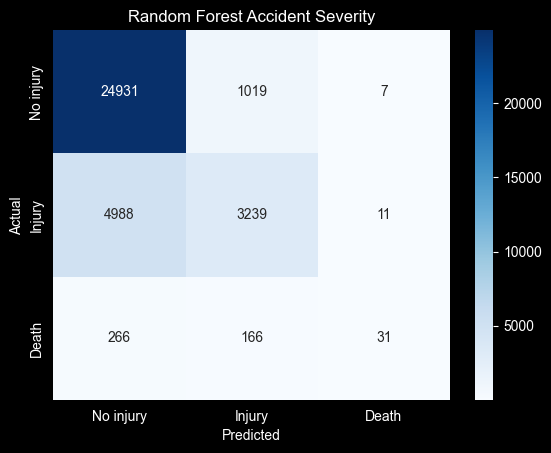

In [76]:
rf_predict_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=5040)
X = combined_df.drop(columns=["Vakavuusko"])
y = combined_df["Vakavuusko"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5040)
rf_predict_model.fit(X_train, y_train)
y_pred = rf_predict_model.predict(X_test)

labels = ["No injury", "Injury", "Death"]
print(classification_report(y_test, y_pred, labels=[0, 2, 1], target_names=labels))
cm = confusion_matrix(y_test, y_pred, labels=[0,2,1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Accident Severity")
plt.show()

The Random Forest model performs well when predicting accidents with no injuries, achieving a good F1-score. This shows that the majority of non-injury accidents are correctly identified.

Performance is noticeably weaker for accidents involving injuries. While the precision for this class is relatively high, the recall is lacking, meaning that a large proportion of injury accidents are incorrectly classified as less severe.

The model performs particularly poorly for fatal accidents. Although the precision is moderate, the recall is quite dreadful, indicating that the model detects only a small fraction of fatal accidents.

Overall, the results suggest that the model is effective at identifying non-severe accidents but struggles to detect more severe outcomes. This is likely influenced by the strong class imbalance in the dataset, where fatal accidents represent only a very small portion of the observations.

The importance of different features is important to understand which is why its good to show a chart of different features and their importance.

Ontyyppi     0.118836
Onluokka     0.116797
X            0.080836
Y            0.078383
Lämpötila    0.065471
Kunta        0.060184
Kk           0.045809
Nopraj       0.042222
Vkpv         0.040976
Vuosi        0.040744
dtype: float64


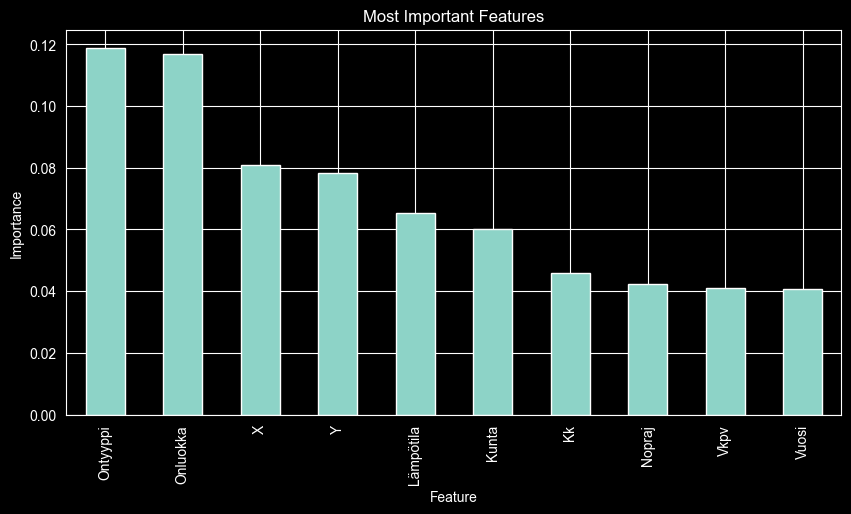

In [82]:
importance = pd.Series(rf_predict_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(10))
importance.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Most Important Features")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.show()

Naturally the accident type has a very strong correlation with the severity of an accident. A crash on the highway is more dangerous than an accident while reversing. Similarly the type of collision is important. Interestingly the coordinates also play a key role in predicting the severity of the accident, but of course once again, the highways are more dangerous. Temperature naturally influences severity among other things.

The Random Forest model offers a solid starting point for predicting accident severity, but exploring other models is essential to fully evaluate predictive performance. Logistic Regression will be examined next.

              precision    recall  f1-score   support

   No injury       0.85      0.46      0.60     17279
      Injury       0.34      0.45      0.38      5530
       Death       0.03      0.58      0.05       297

    accuracy                           0.46     23106
   macro avg       0.40      0.50      0.35     23106
weighted avg       0.72      0.46      0.54     23106



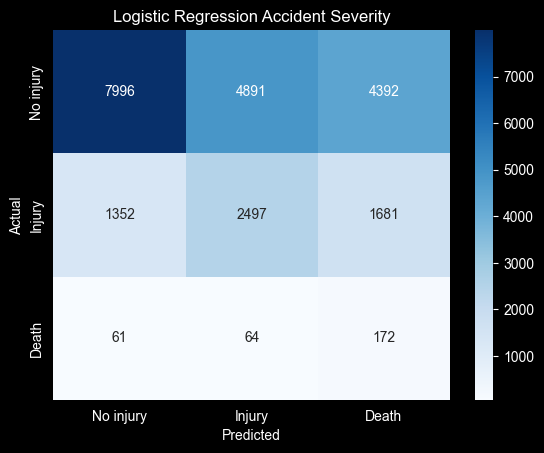

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5040, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
logreg_severity_model = LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=5040)
logreg_severity_model.fit(X_train_scaled, y_train)
y_pred = logreg_severity_model.predict(X_test_scaled)

labels = ["No injury", "Injury", "Death"]
print(classification_report(y_test, y_pred, labels=[0, 2, 1], target_names=labels))
cm = confusion_matrix(y_test, y_pred, labels=[0,2,1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Accident Severity")
plt.show()

Overall Logistic Regression shows far worse results. While there are improvements with the recall of more severe accidents, Everything else is significantly worse.

Next an attempt at predicting results using KNN will be tried.

              precision    recall  f1-score   support

   No injury       0.81      0.91      0.86     17279
      Injury       0.54      0.36      0.43      5530
       Death       0.38      0.02      0.03       297

    accuracy                           0.77     23106
   macro avg       0.58      0.43      0.44     23106
weighted avg       0.74      0.77      0.74     23106



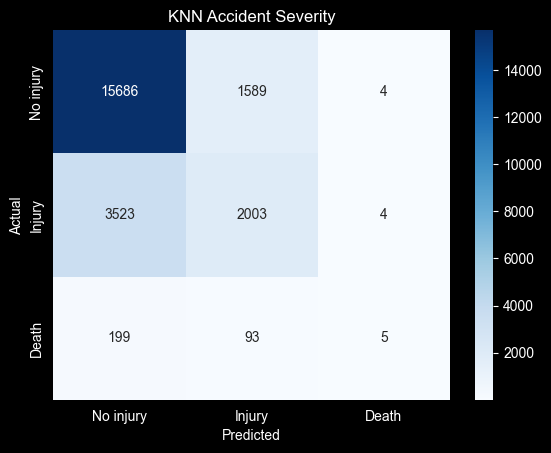

In [79]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn_model = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

labels = ["No injury", "Injury", "Death"]
print(classification_report(y_test, y_pred, labels=[0, 2, 1], target_names=labels))
cm = confusion_matrix(y_test, y_pred, labels=[0,2,1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Accident Severity")
plt.show()

Overall this is an improvement over Logistic Regression, but Random Forest remains king when it comes to predicting the severity of accidents.

While the severity of an accident can be predicted using available data, it is surprisingly difficult. Most accidents are not that severe even when the conditions are pretty bad.